In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.spatial import KDTree

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer, RobustScaler
from sklearn.tree import DecisionTreeRegressor

## Обработка данных

Первоначально построим baseline, просто выкинув все категориальные признаками

In [ ]:
df = pd.read_pickle(r'D:\AV\Education\Master\ML\Project\prepared_data\data.pkl')

In [3]:
df3 = df.copy()

# Преобразуем типы данных
df3['host_response_time'] = df3['host_response_time'].apply(int)
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df3[col] = df3[col].apply(bool)

# Дропаем категориальные признаки
df3 = df3.select_dtypes(include=['int', 'bool', 'float'])

# Для признаков, содержащих мало пропусков, просто выкидываю незаполнные строки
few_null_values_col_list = [
    'host_listings_count',
    'host_total_listings_count',                         
    'minimum_minimum_nights',     
    'maximum_minimum_nights',       
    'minimum_maximum_nights',
    'maximum_maximum_nights',
]
for col in few_null_values_col_list:
    df3 = df3[~df3[col].isna()]

# Признаки, содержащие много пропусков пока просто удаляю
many_null_values_col_list = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'bedrooms',
    'latitude', # 
    'longitude',
]
df3 = df3.drop(columns=many_null_values_col_list)

# Убираю схожие по смыслу признаки
the_same_meaning_col_list = [
    'minimum_minimum_nights',  # Оставлю min_nights
    'maximum_minimum_nights',  # Оставлю min_nights 
    'minimum_nights_avg_ntm',  # Оставлю min_nights
    'minimum_maximum_nights',  # Оставлю max_nights 
    'maximum_maximum_nights',  # Оставлю max_nights 
    'maximum_nights_avg_ntm',  # Оставлю max_nights  
    'number_of_reviews_ltm',  # Оставлю number_of_reviews
    'number_of_reviews_l30d',  # Оставлю number_of_reviews
    'number_of_reviews_ly',  # Оставлю number_of_reviews
    'calculated_host_listings_count_entire_homes',  # Оставлю calculated_host_listings_count
    'calculated_host_listings_count_private_rooms',  # Оставлю calculated_host_listings_count
    'calculated_host_listings_count_shared_rooms',  # Оставлю calculated_host_listings_count
]
df3 = df3.drop(columns=the_same_meaning_col_list)


print(f'Кол-во пропусков = {df3.isnull().sum().sum()}')
print(f'Кол-во признаков = {df3.shape[1]}')
print(f'Кол-во строк = {df3.shape[0]}')

Кол-во пропусков = 0
Кол-во признаков = 19
Кол-во строк = 81820


## KNN (baseline)
Обучим модель KNN на минимально-подготовленных данных

#### Без Scaler

In [4]:
# Делим данные на train и test
X = df3.drop(columns=['availability_30'])
y = df3['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [59]:
# Создадим функцию для подбора и визуализации RMSE в зависимости от числа соседей
def draw_metric(df_list, nm_list, title_nm, metric_col, metric_nm=['rmse', 'r2_score']):

    plt.figure(figsize=(9, 5))

    color_list = ['blue', 'orange', 'green', 'black', 'red', 'grey']

    for i, df in enumerate(df_list):

        plt.plot(df['n'], df[metric_col], label=nm_list[i], color=color_list[i])

        if metric_nm == 'rmse': 

            # Находим минимальное значение метрики для RMSE 
            min_idx = df[metric_col].idxmin()
            min_rmse = df.loc[min_idx, metric_col]
            min_n = df.loc[min_idx, 'n']
        
            plt.scatter(min_n, min_rmse, color=color_list[i], zorder=5,
                    label=f"{nm_list[i]} min RMSE : {min_rmse:.4f} (n={min_n})")
            
        elif metric_nm == 'r2_score':

            # Находим максимальное значение метрики для r2_score
            max_idx = df[metric_col].idxmax()
            max_r2 = df.loc[max_idx, metric_col]
            max_n = df.loc[max_idx, 'n']
        
            plt.scatter(max_n, max_r2, color=color_list[i], zorder=5,
                    label=f"{nm_list[i]} max r2_score : {max_r2:.4f} (n={max_n})")

    plt.legend()
    plt.title(title_nm)

100%|██████████| 38/38 [00:21<00:00,  1.77it/s]


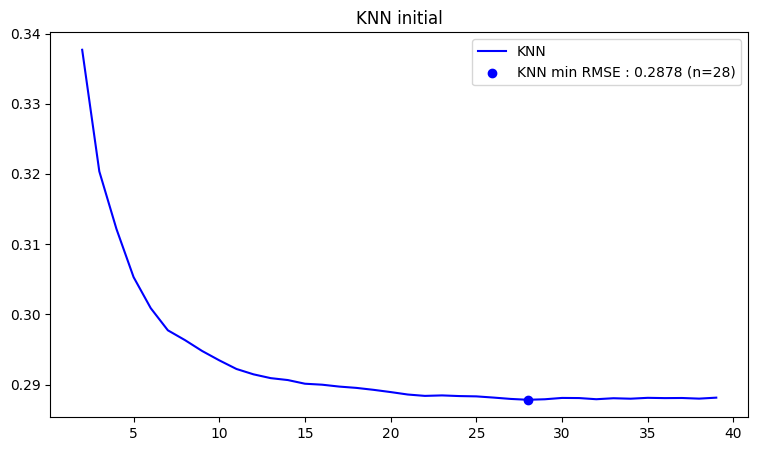

In [ ]:
res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train, y_train)

    y_test_pred = knn.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

knn_initial_df = pd.DataFrame(res)

draw_metric([knn_initial_df], ['KNN'], title_nm='KNN initial', metric_nm='rmse_test')

#### Применение StandardScaler
Попробуем улучшить качество KNN за счет применение StandardScaler

100%|██████████| 38/38 [00:27<00:00,  1.38it/s]


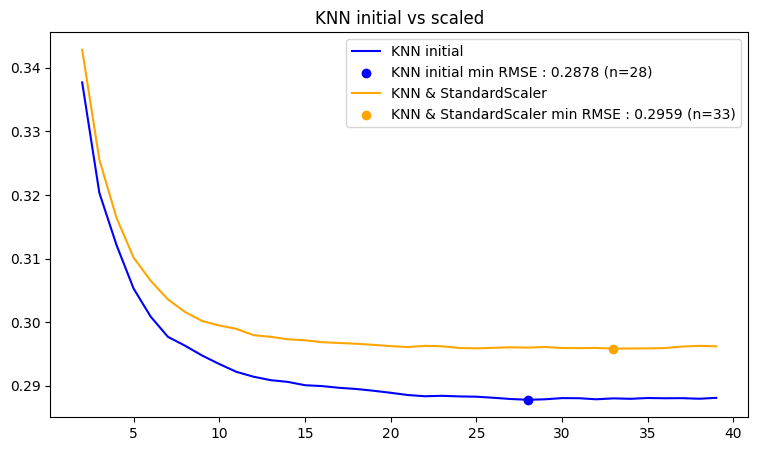

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled, y_train)

    y_test_pred = knn.predict(X_test_scaled)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

knn_scaled_df = pd.DataFrame(res)

draw_metric(
    [knn_initial_df, knn_scaled_df],
    ['KNN initial', 'KNN & StandardScaler'],
    title_nm='KNN initial vs scaled',
    metric_nm='rmse_test',
)


Применение StandardScaler увеличило RMSE. Это может объясняться следующими факторами:
* Наличие существенных выбросов в данных (из-за этого среднее может сильно искажаться)
* Большое кол-во 0 в фичах

Проверим данные на наличие этих факторов


In [18]:
# Функция размечающая выбросы по методу IQR +- 1.5 IQR
def find_outlier(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    iqr = q3 - q1

    return (x > q3 + iqr * 1.5) | (x < q1 - iqr * 1.5)

In [ ]:
# Посмотрим на долю выбросов и наибольшее отклонение выброса в каждом столбце
for col in df3.select_dtypes(include=['int', 'float']).columns:

    # Считаем долю выбросов в признаке
    outlier_perc = find_outlier(df3[col]).mean()

    iqr = df3[col].quantile(0.75) - df3[col].quantile(0.25)

    # Считаем на сколько IQR отклонилось максимальное значение от Q3
    n_iqr = (df3[col].max() - df3[col].quantile(0.75)) / iqr

    print(f'{col}: outlier_perc = {outlier_perc:.2%} max_iqr_deviation = {n_iqr:.2f}')

host_response_time: outlier_perc = 0.00% max_iqr_deviation = 0.00
host_response_rate: outlier_perc = 0.00% max_iqr_deviation = 0.00
host_acceptance_rate: outlier_perc = 0.00% max_iqr_deviation = 0.01
host_listings_count: outlier_perc = 19.64% max_iqr_deviation = 2765.67
host_total_listings_count: outlier_perc = 18.50% max_iqr_deviation = 1752.60
accommodates: outlier_perc = 2.60% max_iqr_deviation = 6.00
minimum_nights: outlier_perc = 21.62% max_iqr_deviation = 248.50
maximum_nights: outlier_perc = 0.00% max_iqr_deviation = 9215.55
availability_30: outlier_perc = 12.90% max_iqr_deviation = 2.33
number_of_reviews: outlier_perc = 10.14% max_iqr_deviation = 148.59
calculated_host_listings_count: outlier_perc = 19.22% max_iqr_deviation = 406.50
host_age_on_platform: outlier_perc = 0.00% max_iqr_deviation = 1.04


Действительно, есть признаки, которые содержат большое кол-во выбросов. 

Попробуем и сравним между собой следующие подходы:
* Используем RobustScaler вместо StandardScaler
* Используем ln(1+x) в качеству скейлера
* Заменим выбросы на значение Q3 + 1.5 IQR или Q1 - 1.5 IQR 

#### Применение RobustScaler

In [27]:
scaler = RobustScaler()

X_train_scaled2 = scaler.fit_transform(X_train) 
X_test_scaled2 = scaler.transform(X_test)

# Создадим пустой справочник для сохранения значений
res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train)

    y_test_pred = knn.predict(X_test_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

knn_robust_scaler_df = pd.DataFrame(res)

100%|██████████| 38/38 [00:29<00:00,  1.27it/s]


#### Применение log1p

In [28]:
scaler = FunctionTransformer(np.log1p, validate=True)

X_train_scaled2 = scaler.fit_transform(X_train) 
X_test_scaled2 = scaler.transform(X_test)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train)

    y_test_pred = knn.predict(X_test_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

knn_log1p_scaler_df = pd.DataFrame(res)

100%|██████████| 38/38 [00:25<00:00,  1.46it/s]


#### Замена выбросов

Попробуем заменить выбросы, на значения равные Q3 + 1.5 IQR или Q1 - 1.5 IQR в зависимости от направления выброса

In [19]:
df4 = df3.copy()

for col in df4.select_dtypes(include=['int', 'float']).columns:

    if col != 'availability_30':  # не трогаем таргет
    

        q1 = df4[col].quantile(0.25)
        q3 = df4[col].quantile(0.75)
        iqr = q3 - q1

        df4[col] = df4[col].apply(lambda x: q3 + 1.5 * iqr if x > q3 + 1.5 * iqr else x)
        df4[col] = df4[col].apply(lambda x: q1 - 1.5 * iqr if x < q1 - 1.5 * iqr else x)

        # Считаем долю выбросов в признаке
        outlier_perc = find_outlier(df4[col]).mean()

        # Выводим значение
        print(f'{col}: outlier_perc = {outlier_perc:.2%}')



host_response_time: outlier_perc = 0.00%
host_response_rate: outlier_perc = 0.00%
host_acceptance_rate: outlier_perc = 0.00%
host_listings_count: outlier_perc = 0.00%
host_total_listings_count: outlier_perc = 0.00%
accommodates: outlier_perc = 0.00%
minimum_nights: outlier_perc = 0.00%
maximum_nights: outlier_perc = 0.00%
number_of_reviews: outlier_perc = 0.00%
calculated_host_listings_count: outlier_perc = 0.00%
host_age_on_platform: outlier_perc = 0.00%


In [29]:
# Примененим StandardScaler
scaler = StandardScaler()
X2 = df4.drop(columns='availability_30')
y2 = df4['availability_30']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y)
X_train_scaled2 = scaler.fit_transform(X_train2) 
X_test_scaled2 = scaler.transform(X_test2)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train2)

    y_test_pred = knn.predict(X_test_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test2,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test2,y_pred=y_test_pred)]

knn_oulier_replacement_df = pd.DataFrame(res)

100%|██████████| 38/38 [00:25<00:00,  1.47it/s]


#### Итоговое сравнение всех scalers на KNN

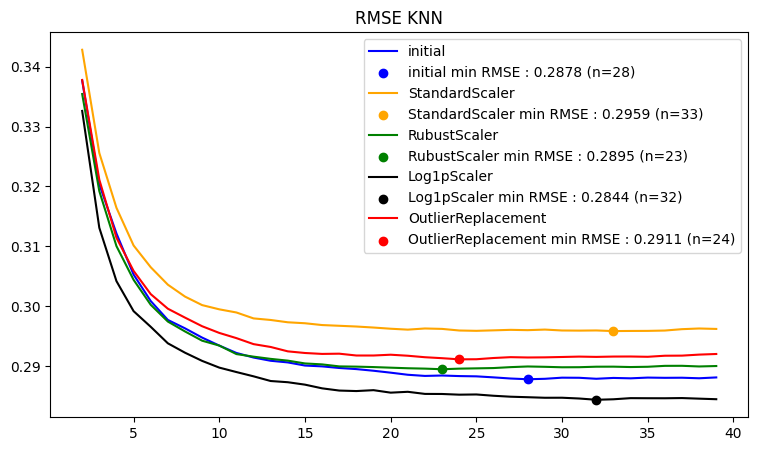

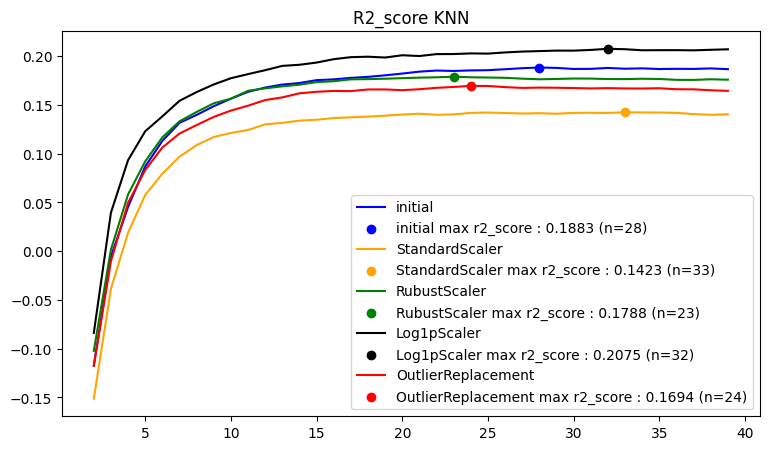

In [ ]:
draw_metric(
    [knn_initial_df, knn_scaled_df, knn_robust_scaler_df, knn_log1p_scaler_df, knn_oulier_replacement_df],
    ['initial', 'StandardScaler', 'RubustScaler', 'Log1pScaler', 'OutlierReplacement'],
    title_nm='RMSE KNN',
    metric_col='rmse_test',
    metric_nm='rmse'
)

draw_metric(
    [knn_initial_df, knn_scaled_df, knn_robust_scaler_df, knn_log1p_scaler_df, knn_oulier_replacement_df],
    ['initial', 'StandardScaler', 'RubustScaler', 'Log1pScaler', 'OutlierReplacement'],
    title_nm='R2_score KNN',
    metric_col='r2_score',
    metric_nm='r2_score'
)

**Вывод:**
Лучше всего себя показывает использование Log(1+x). 

**На KNN получаем следующий baseline:**
* RMSE = 0.2844
* R^2 = 0.2075

При этом модель довольно плохо предсказывает значение целевой переменной, тк алгоритм объясняет всего 21% дисперсии

Добавим значения basilne в функцию draw_metric2

In [213]:
# Создадим функцию для подбора и визуализации RMSE в зависимости от числа соседей
def draw_metric2(df_list, nm_list, title_nm, metric_col, metric_nm=['rmse', 'r2_score'], x_label_name=None, y_label_name=None):

    plt.figure(figsize=(9, 5))

    color_list = ['blue', 'orange', 'green', 'black', 'red', 'grey']

    for i, df in enumerate(df_list):

        plt.plot(df['n'], df[metric_col], label=nm_list[i], color=color_list[i])

        if metric_nm == 'rmse': 

            # Находим минимальное значение метрики для RMSE 
            min_idx = df[metric_col].idxmin()
            min_rmse = df.loc[min_idx, metric_col]
            min_n = df.loc[min_idx, 'n']
        
            plt.scatter(min_n, min_rmse, color=color_list[i], zorder=5,
                    label=f"{nm_list[i]} min RMSE : {min_rmse:.4f} (n={min_n})")
            
            # Рисум baseline
            plt.plot(df['n'], np.full(len(df), 0.2844), label='baseline = 0.2844', color='brown')
            
        elif metric_nm == 'r2_score':

            # Находим максимальное значение метрики для r2_score
            max_idx = df[metric_col].idxmax()
            max_r2 = df.loc[max_idx, metric_col]
            max_n = df.loc[max_idx, 'n']
        
            plt.scatter(max_n, max_r2, color=color_list[i], zorder=5,
                    label=f"{nm_list[i]} max r2_score : {max_r2:.4f} (n={max_n})")
            
            # Рисум baseline
            plt.plot(df['n'], np.full(len(df), 0.2075), label='baseline = 0.2075', color='brown')

    plt.legend()
    plt.title(title_nm)
    plt.xlabel(x_label_name)
    plt.ylabel(y_label_name)

## DecisionTreeRegressor

Далее попробуем использование DecisionTreeRegressor.

В отличие от KNN модель не чувствительная к выбросам, поэтому можем использовать данные без применения скейлеров.

Попробуем подобрать наиболее эффективное значение гиперараметра min_samples_leaf - минимальный размер выборки, который может быть в ноде

In [53]:
# Делим данные на train и test
X = df3.drop(columns=['availability_30'])
y = df3['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

100%|██████████| 100/100 [00:13<00:00,  7.53it/s]


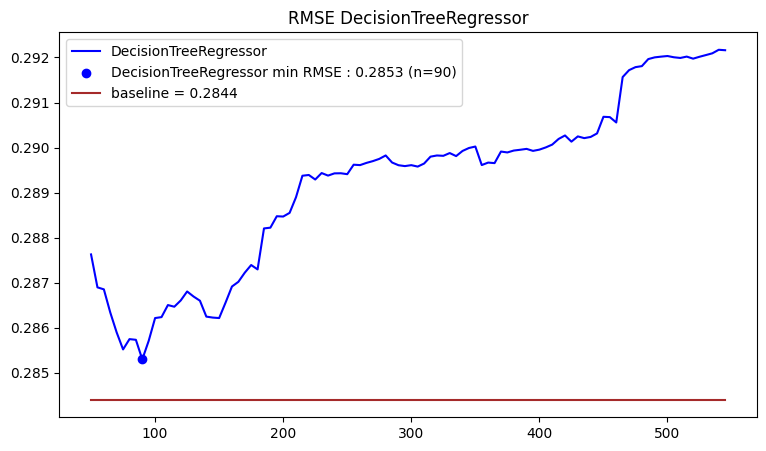

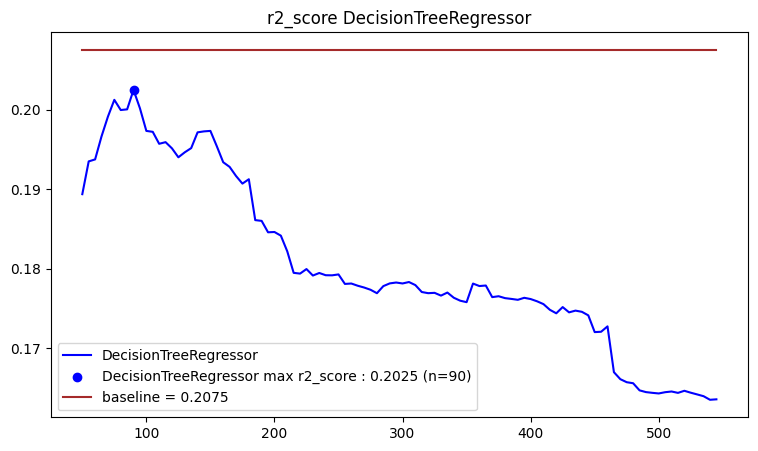

In [70]:
res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(50, 550, 5)):

    tree_reg = DecisionTreeRegressor(min_samples_leaf=n)


    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['DecisionTreeRegressor'],
    title_nm='RMSE DecisionTreeRegressor',
    metric_col='rmse_test',
    metric_nm='rmse'
)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['DecisionTreeRegressor'],
    title_nm='r2_score DecisionTreeRegressor',
    metric_col='r2_score',
    metric_nm='r2_score'
)

## XGBRegressor

In [5]:
import xgboost as xgb

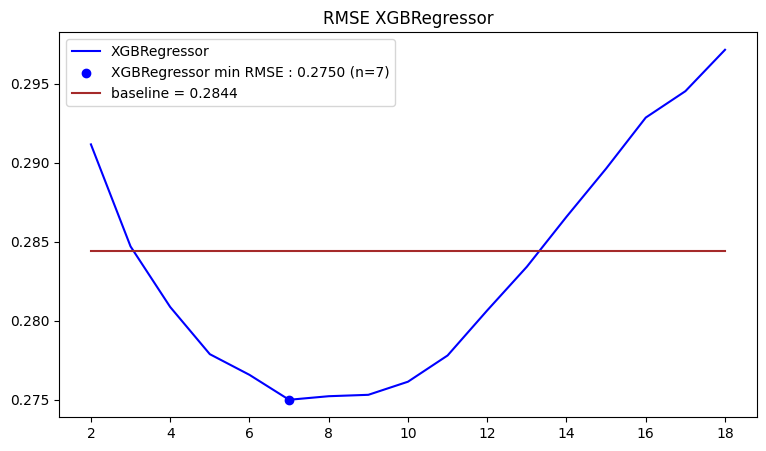

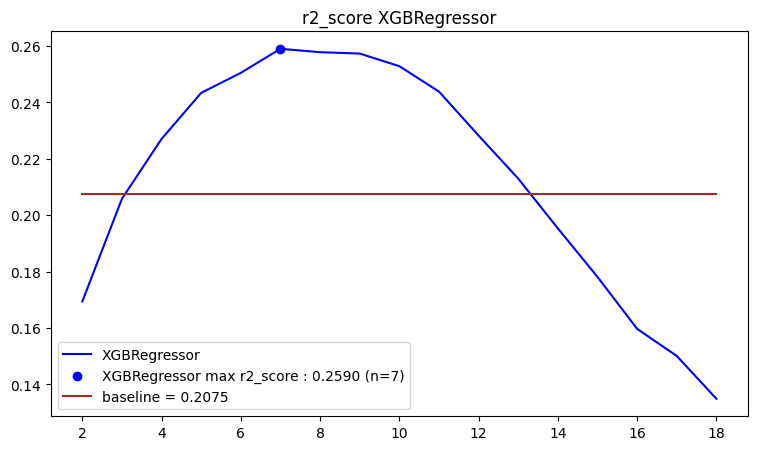

In [ ]:
res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}


for n in tqdm(range(2, 19)):

    tree_reg = xgb.XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,    
    max_depth=n,            
    objective='reg:squarederror', 
    random_state=42
)

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='RMSE XGBRegressor',
    metric_col='rmse_test',
    metric_nm='rmse'
)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='r2_score XGBRegressor',
    metric_col='r2_score',
    metric_nm='r2_score'
)

DecisionTreeRegressor не показал качество модели выше чем baseline, что странно...

Возможно, дело в самих признаках, посмотрим на них внимательнее. Построим корреляционную матрицу

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

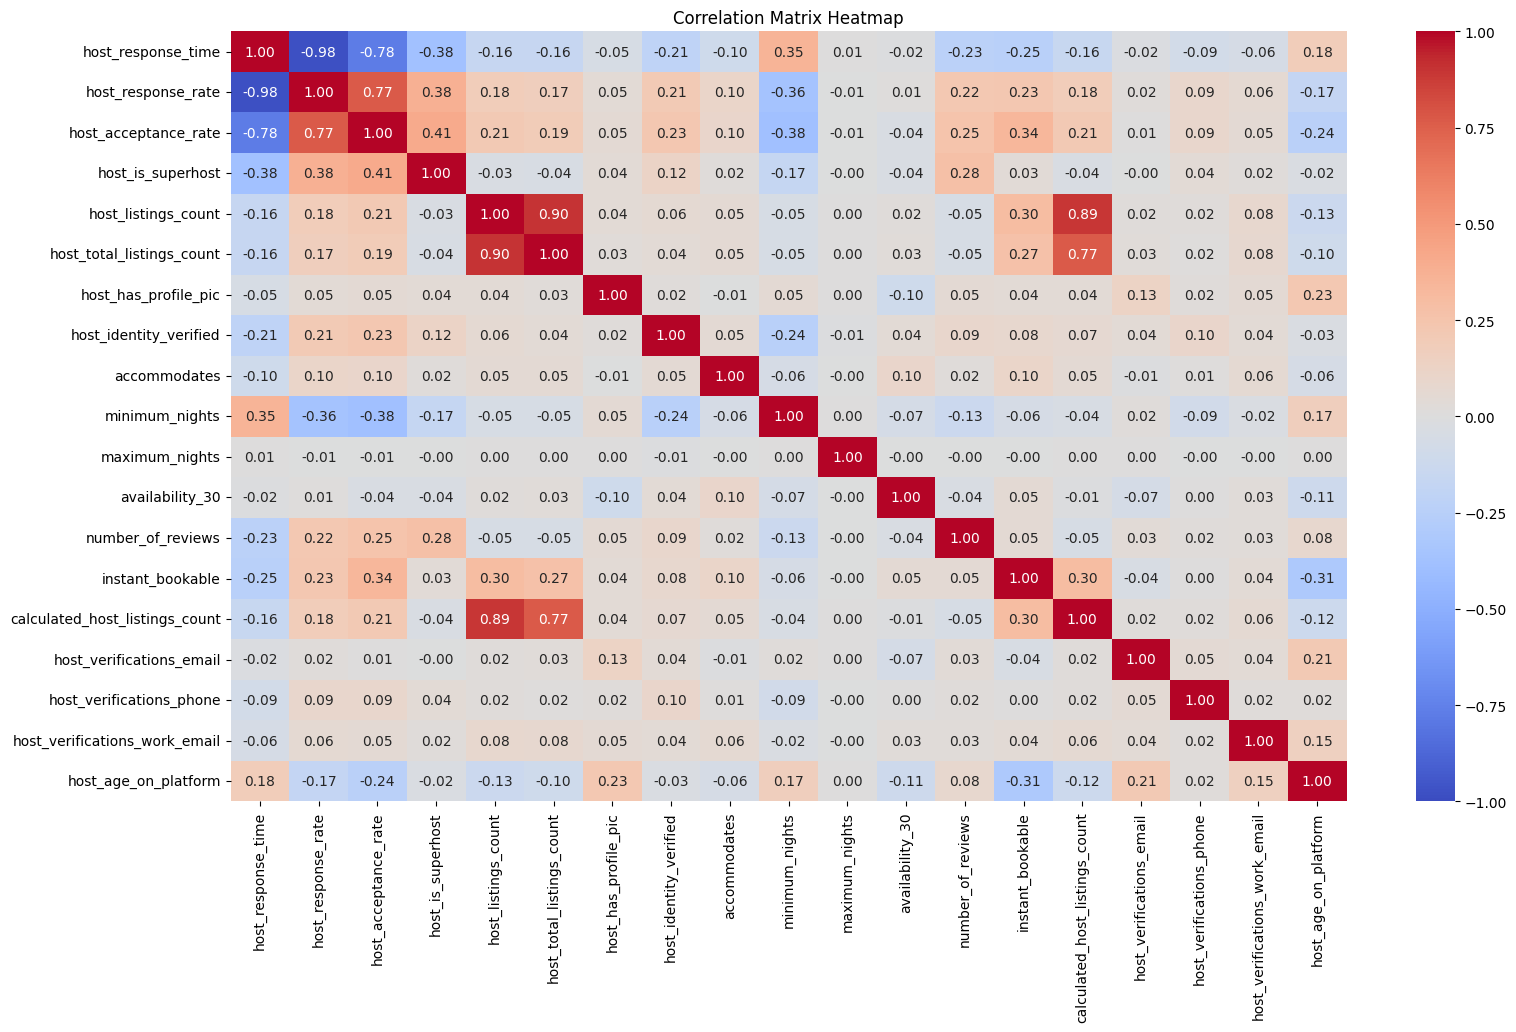

In [ ]:
corr_matrix = df3.corr()

plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Heatmap')

## Промежуточные выводы

В корреляционной матрице видим:
1. Все имеющиеся признаки обладают очень слабой линейной зависимостью с целевой переменно availablity_30. Это может говорить об отсутствии в датасете признаков, влияющих на целевую переменную либо о наличии нелинейных зависимостей
2. Есть ряд признаков, которые сильно коррелируют друг с другом. Можно попробовать избавиться от них для повышения качества работы модели

**Далее попробуем улучшить качество модели за счет более детальной работы с признаками**

## Работа с признаками

### Предобработка данных

In [10]:
df6 = df.copy()

# Преобразуем типы данных
df6['host_response_time'] = df6['host_response_time'].apply(int)
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df6[col] = df6[col].apply(bool)

# Для признаков, содержащих мало пропусков, просто выкидываю незаполнные строки
few_null_values_col_list = [
    'host_listings_count',
    'host_total_listings_count',                         
    'minimum_minimum_nights',     
    'maximum_minimum_nights',       
    'minimum_maximum_nights',
    'maximum_maximum_nights',
]
for col in few_null_values_col_list:
    df6 = df6[~df6[col].isna()]

# Признаки, содержащие много пропусков пока просто удаляю
# many_null_values_col_list = [
#     'review_scores_rating',
#     'review_scores_accuracy',
#     'review_scores_cleanliness',
#     'review_scores_checkin',
#     'review_scores_communication',
#     'review_scores_location',
#     'review_scores_value',
#     'reviews_per_month',
#     'bedrooms',
#     'latitude', # 
#     'longitude',
# ]
# df6 = df6.drop(columns=many_null_values_col_list)

# Убираю схожие по смыслу признаки
the_same_meaning_col_list = [
    'minimum_minimum_nights',  # Оставлю min_nights
    'maximum_minimum_nights',  # Оставлю min_nights 
    'minimum_nights_avg_ntm',  # Оставлю min_nights
    'minimum_maximum_nights',  # Оставлю max_nights 
    'maximum_maximum_nights',  # Оставлю max_nights 
    'maximum_nights_avg_ntm',  # Оставлю max_nights  
    'number_of_reviews_ltm',  # Оставлю number_of_reviews
    'number_of_reviews_l30d',  # Оставлю number_of_reviews
    'number_of_reviews_ly',  # Оставлю number_of_reviews
    'calculated_host_listings_count_entire_homes',  # Оставлю calculated_host_listings_count
    'calculated_host_listings_count_private_rooms',  # Оставлю calculated_host_listings_count
    'calculated_host_listings_count_shared_rooms',  # Оставлю calculated_host_listings_count
]
df6 = df6.drop(columns=the_same_meaning_col_list)


print(f'Кол-во пропусков = {df6.isnull().sum().sum()}')
print(f'Кол-во признаков = {df6.shape[1]}')
print(f'Кол-во строк = {df6.shape[0]}')

Кол-во пропусков = 372869
Кол-во признаков = 45
Кол-во строк = 81820


### Устранение высокой корреляций признаков между собой

Text(0.5, 1.0, 'Корреляционная матрица до чистки признаков')

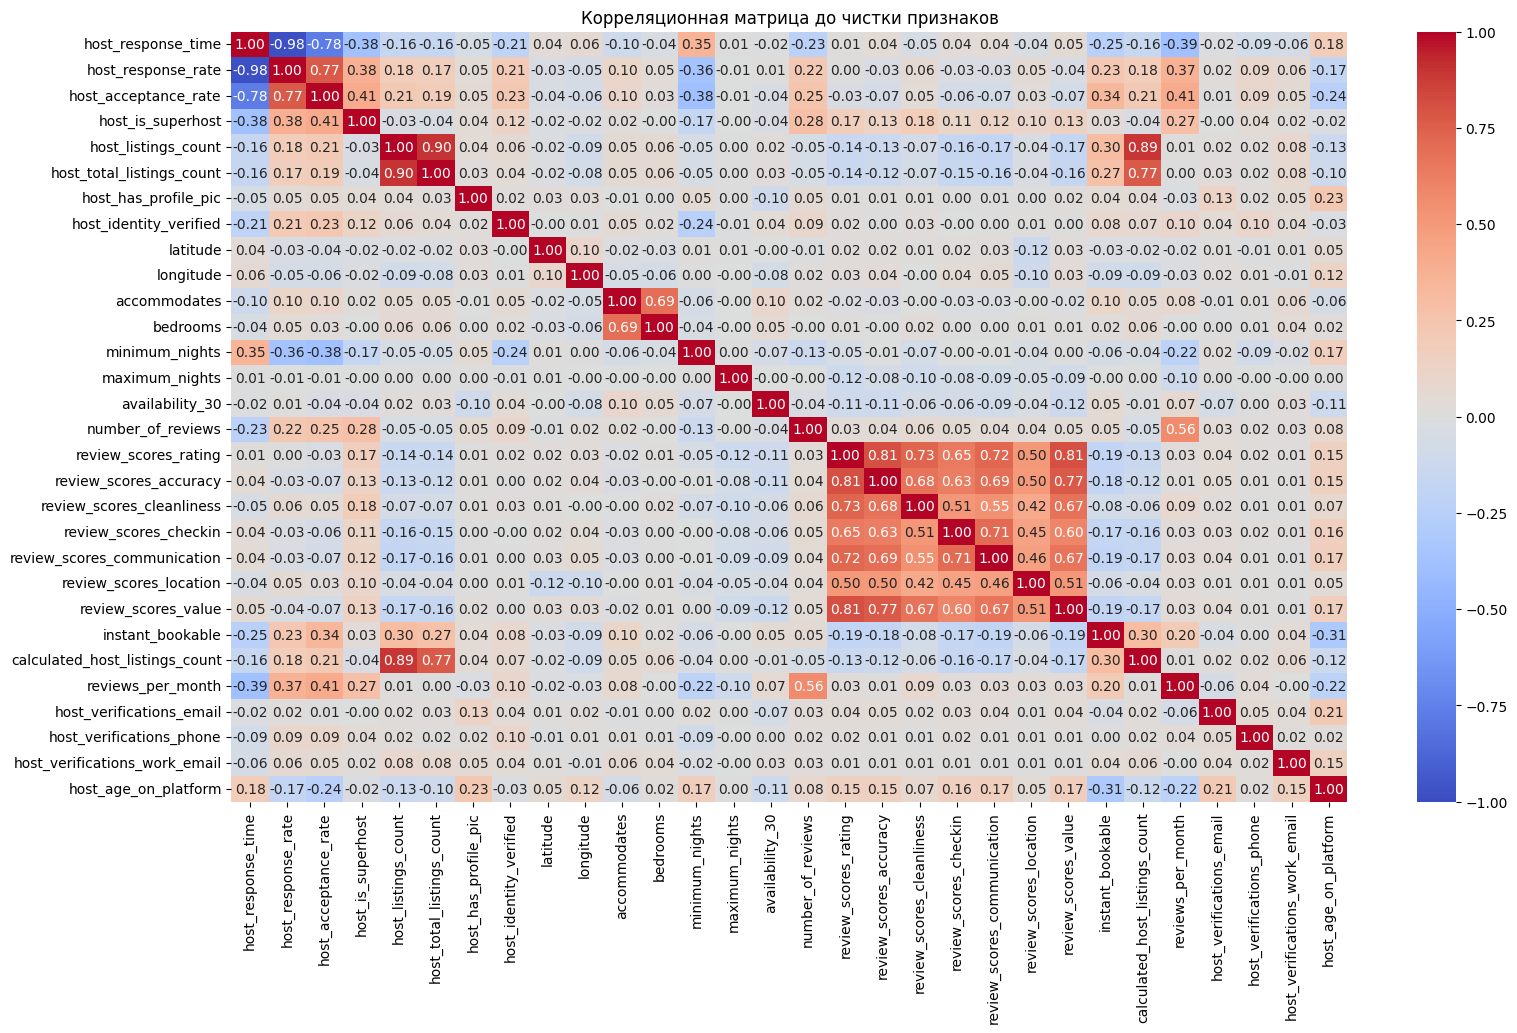

In [35]:
corr_matrix = df6.select_dtypes(['bool', 'int', 'float']).corr()

plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Корреляционная матрица до чистки признаков')

In [174]:
df7 = df6.copy()

high_corr_col_list = [
    'host_response_time',  # корреляция с host_response_rate
    'host_acceptance_rate',  # корреляция с host_response_rate
    'host_listings_count',  # корреляция с host_total_listings_count
    'calculated_host_listings_count',  # корреляция с host_total_listings_count
    'review_scores_rating',   # корреляция с review_scores_value
    'review_scores_accuracy',  # корреляция с review_scores_value
    'review_scores_cleanliness',   # корреляция с review_scores_value
    'review_scores_checkin',  # корреляция с review_scores_value
    'review_scores_communication',   # корреляция с review_scores_value
    'review_scores_location',  # корреляция с review_scores_value
    'reviews_per_month',  # корреляция с number_of_reviews
    'bedrooms',  # корреляций с accommodates
]

# Заполним пустые значения скора как -1
df7['review_scores_value'] = df7['review_scores_value'].fillna('-1').apply(float)

df7 = df7.drop(columns=high_corr_col_list)

Text(0.5, 1.0, 'Корреляционная матрица после чистки признаков')

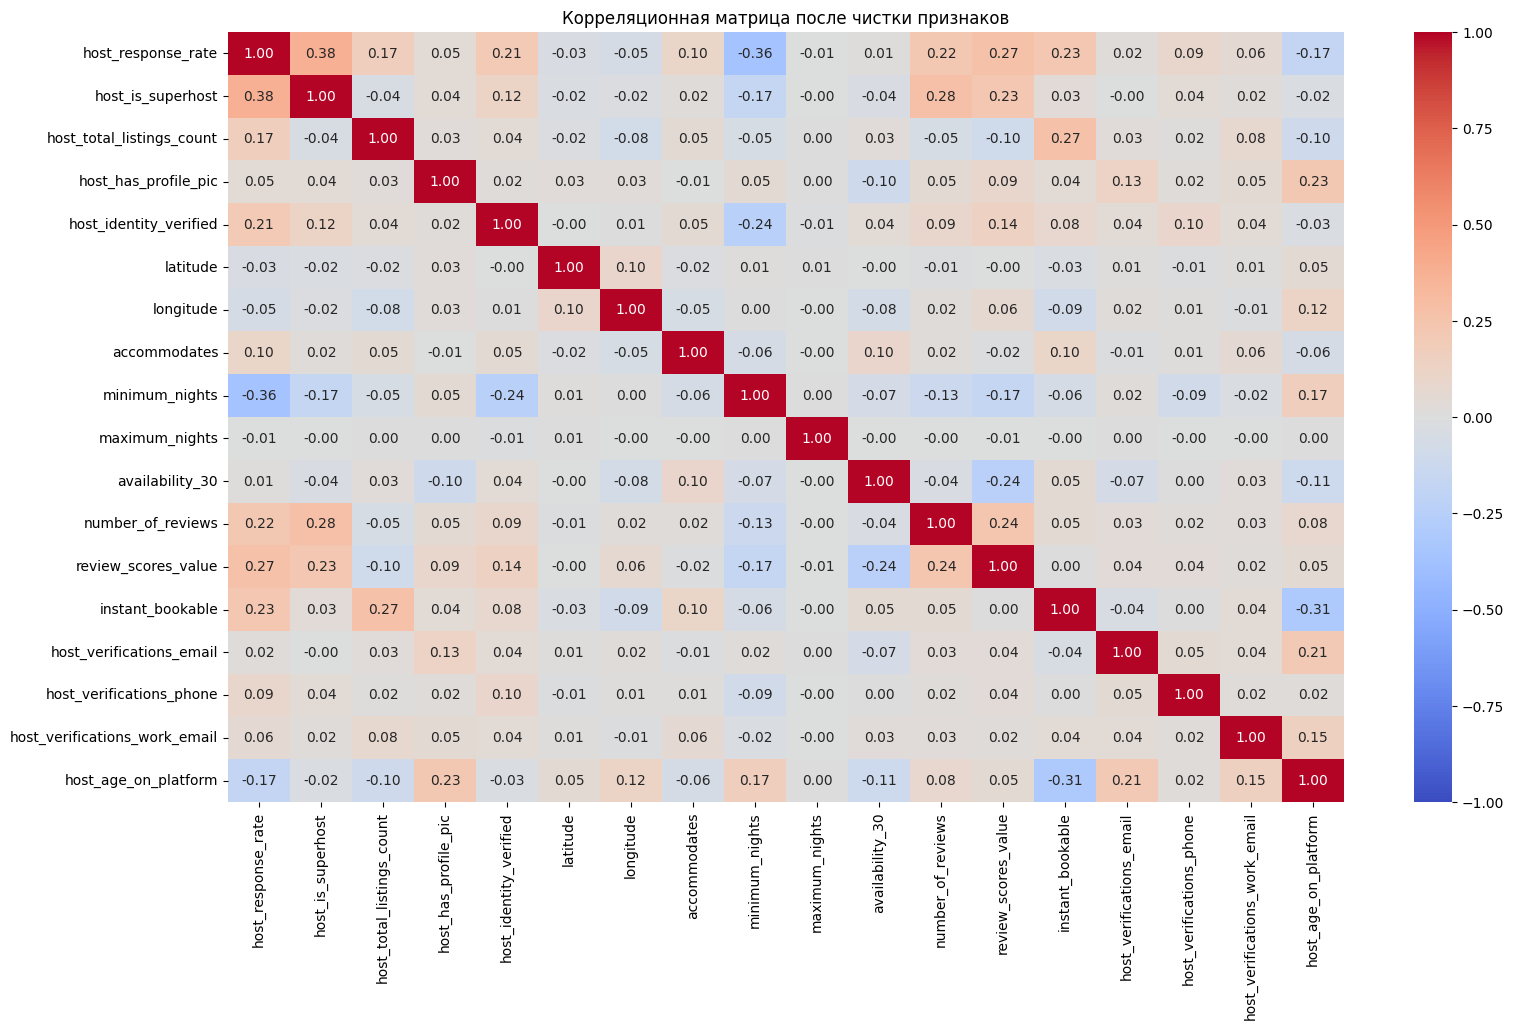

In [175]:
corr_matrix = df7.select_dtypes(['bool', 'int', 'float']).corr()

plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Корреляционная матрица после чистки признаков')

100%|██████████| 11/11 [00:04<00:00,  2.71it/s]


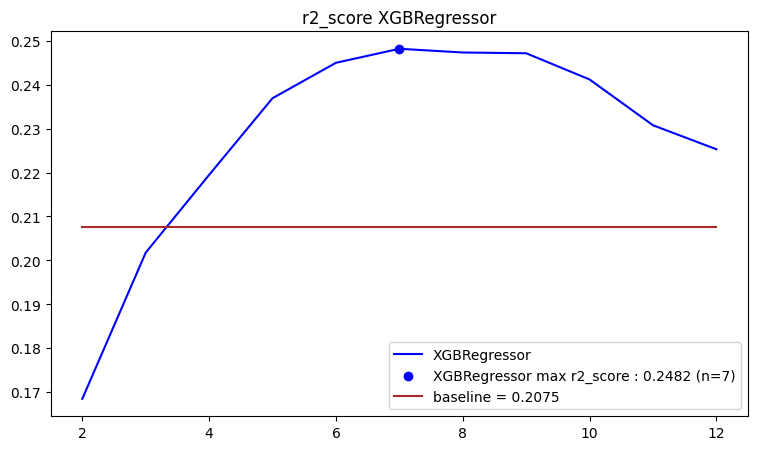

In [176]:
# Делим данные на train и test
X = df7.select_dtypes(['bool', 'int', 'float']).drop(columns=['availability_30'])
y = df7['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 13)):

    tree_reg = xgb.XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,    
    max_depth=n,            
    objective='reg:squarederror', 
    random_state=42
)

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='r2_score XGBRegressor',
    metric_col='r2_score',
    metric_nm='r2_score'
)

**Вывод:**

Удаление признаков не улучшило качество модели. Попробуем поработать с категориальными признаками

### Обработка категориальных признаков

In [177]:
df8 = df7.copy()

# Преобразуем опсиание в длинну описания по логике, чем подробнее описание, тем лучше
df8['description'] = df8['description'].apply(lambda x: len(str(x)))

# Преобразуем в bool по логике, что жильцы хотели бы, чтобы хост был в том же городе
df8['host_location'] = df8['host_location'] == 'Paris, France'

# В признаке property_type содержится 61 значение, декодируем до 4х
def get_property_type(x):
    if x == 'Entire rental unit':
        return 'flat'
    elif 'room' in x.lower():
        return 'room'
    elif 'hotel' in x.lower():
        return 'hotel'
    else: 
        return 'other'
df8['property_type'] = df8['property_type'].apply(get_property_type)

# Переводим в bool через one hot encoding. Посследнюю дропаем, тк она полностью зависит от остальных
property_types_df = pd.get_dummies(df8['property_type'], drop_first=True)
df8 = pd.concat([df8, property_types_df], axis=1)

# Заполняем на наличие лицензии
df8['license'] = df8['license'].isna()

# Считаем кол-во итемов в объекте
df8['amenities'] = df8['amenities'].apply(lambda x: x.count(','))

drop_list = [
    'neighborhood_overview',  # Дропаем из-за большой корреляции кол-ва символов с description
    'host_about',  # Дропаем из-за большой корреляции кол-ва символов с description
    'name',  # Дропаем из-за большой корреляции кол-ва символов с description
    'host_neighbourhood',  # Пока просто дропаем
    'neighbourhood_cleansed',  # Пока просто дропаем
    'property_type',  # не нужно, так как мы раскрыли через one hot encoding
    'room_type',  # Тоже самое что и property_type
    'bathrooms_text',  # Пока просто дропаем
    'first_review',  # Пока просто дропаем
    'last_review',  # Пока просто дропаем
    
]
df8 = df8.drop(columns=drop_list)

df8.select_dtypes(['str']).columns

Index([], dtype='str')

100%|██████████| 11/11 [00:04<00:00,  2.22it/s]


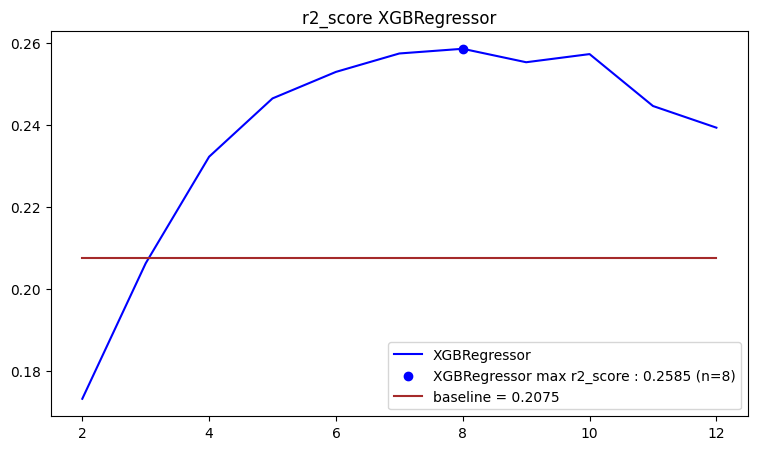

In [178]:
# Делим данные на train и test
X = df8.select_dtypes(['bool', 'int', 'float']).drop(columns=['availability_30'])
y = df8['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 13)):

    tree_reg = xgb.XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,    
    max_depth=n,            
    objective='reg:squarederror', 
    random_state=42
)

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='r2_score XGBRegressor',
    metric_col='r2_score',
    metric_nm='r2_score'
)

Text(0.5, 1.0, 'Корреляционная матрица поле добавления новых признаков')

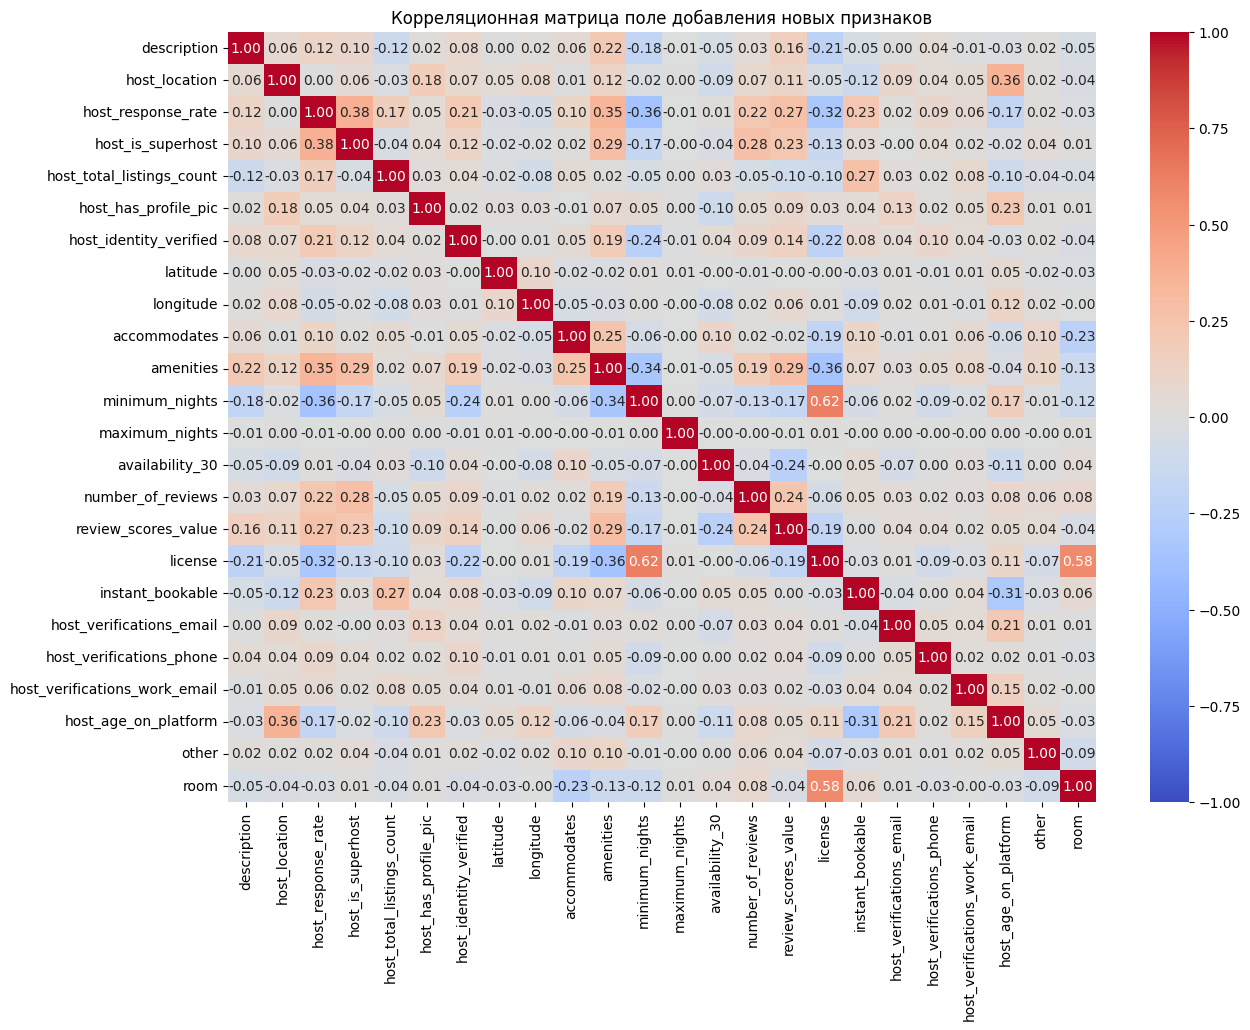

In [179]:
corr_matrix = df8.select_dtypes(['bool', 'int', 'float']).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Корреляционная матрица поле добавления новых признаков')

**Промежуточный вывод:**

Добавление новых признаков увеличило качество модели по метрике R^2 на ~0.1

**Однако**, до сих пор нет признаков коррелирующих с целевой переменной. Попроуем сформировать новые признаки


### Feature enginiring (локация)

Поработаем с локацией объекта, т.к. логически, это должен быть важным признаком для туристов

Получим следующие группы признаков:
1. Расстояние до ключевых достопримечательностей Парижа
2. Расстояние до ближайшего метро

Для нахождения расстояния между двумя координатми воспользуемся формулой Haversine:
$$a = \sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1) \cdot \cos(\phi_2) \cdot \sin^2\left(\frac{\Delta \lambda}{2}\right)$$
$$c = 2 \cdot \operatorname{atan2}\left(\sqrt{a}, \sqrt{1-a}\right)$$
$$d = R \cdot c$$

где:
* φ₁, φ₂: Широта точки 1 и 2 (в радианах)
* λ₁, λ₂: Долгота точки 1 и 2 (в радианах)
* R: Радиус Земли (6.371 км)
* Δ φ: φ₂ - φ₁ разница в широтах
* Δ λ: λ₂ - λ₁ разница в долготах


In [180]:
def haversine_distance(lat1, lon1, lat2, lon2):

    # Радиус Земли в км.
    R = 6371.0  

    # Преобразуем в радианы и находим разнцицу в широте и долготе между точками
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c

    return distance

#### Расстояние до достопримечательностей

In [181]:
df9 = df8.copy()

# Создадим словарь с координатами основных достопримечательностей Парижа
sighseeng_coordinates = {
    'Eiffel Tower': (48.8584, 2.2945), 
    'ELouvre Museum': (48.8606, 2.3376), 
    'ENotre-Dame Cathedral': (48.8530, 2.3499), 
    'EArc de Triomphe': (48.8738, 2.2950), 
    "EMusée d'Orsay": (48.8600, 2.3266), 
    'ESacré-Cœur Basilica': (48.8867, 2.3431),
    'EChamps-Élysées': (48.8705, 2.3049),
}

# Считаем расстояние до достопримечательностей
for col in sighseeng_coordinates:
    df9['distance_' + col] = df9.apply(lambda x: haversine_distance(
        lat1=x.latitude,
        lon1=x.longitude, 
        lat2=sighseeng_coordinates[col][0],
        lon2=sighseeng_coordinates[col][1],
        ), axis=1
        )


#### Расстояние до ближайшего метро

In [182]:
# Грузим координаты всех станций метро Парижа
metro_df = pd.read_csv('prepared_data\metro_rer_idf.csv')

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\alrvt\AppData\Local\Temp\ipykernel_32472\3568527186.py:2: SyntaxWarning: invalid escape sequence '\m'
  metro_df = pd.read_csv('prepared_data\metro_rer_idf.csv')


In [183]:
# Создадим отдельную функцию для поиска билжайшего метро
# Пришлось делать отдельную, т.к. Python не тянул cross join и затем фильтрацию
def find_nearest_metro(df, df_metro):

    # Переводим в радианы
    metro_coords = np.radians(df_metro[["latitude", "longitude"]].values)
    airbnb_coords = np.radians(df[["latitude", "longitude"]].values)

    # Строим дерево на основании координат метро
    tree = KDTree(metro_coords)

    # Строим дерево
    distances_rad, indices = tree.query(airbnb_coords, k=1)

    R = 6371.0

    df["distance_to_metro_km"] = distances_rad * R

    return df

df9 = find_nearest_metro(df9, metro_df)

df9 = df9.drop(columns=['latitude', 'longitude'])

Text(0.5, 1.0, 'Корреляционная матрица поле добавления новых признаков')

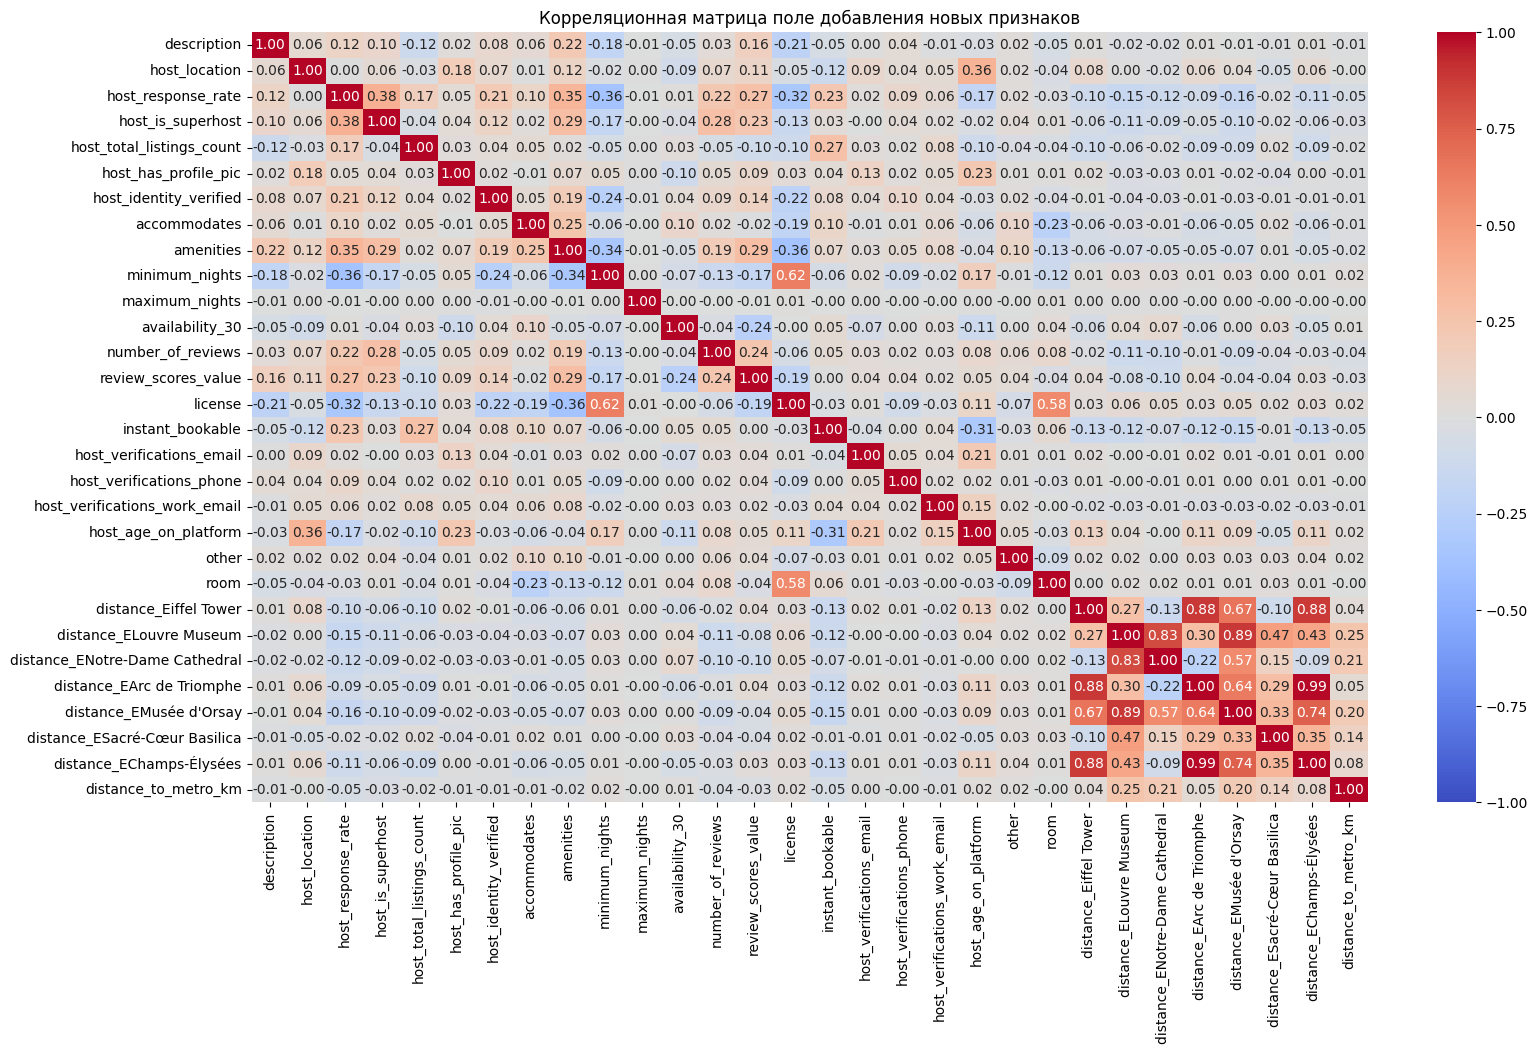

In [184]:
corr_matrix = df9.select_dtypes(['bool', 'int', 'float']).corr()

plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Корреляционная матрица поле добавления новых признаков')

100%|██████████| 11/11 [00:06<00:00,  1.83it/s]


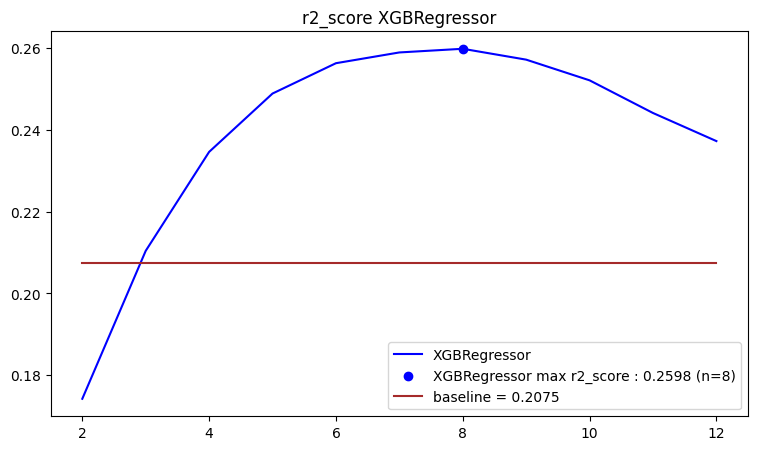

In [191]:
# Делим данные на train и test
X = df9.select_dtypes(['bool', 'int', 'float']).drop(columns=['availability_30'])
y = df9['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

for n in tqdm(range(2, 13)):

    tree_reg = xgb.XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,    
    max_depth=n,            
    objective='reg:squarederror', 
    random_state=42
)

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='r2_score XGBRegressor',
    metric_col='r2_score',
    metric_nm='r2_score'
)

## Final

### Уменьшение кол-ва признаков

Попробуем повысить качество можели за счет отбора только самых важных признаков

100%|██████████| 28/28 [00:08<00:00,  3.47it/s]


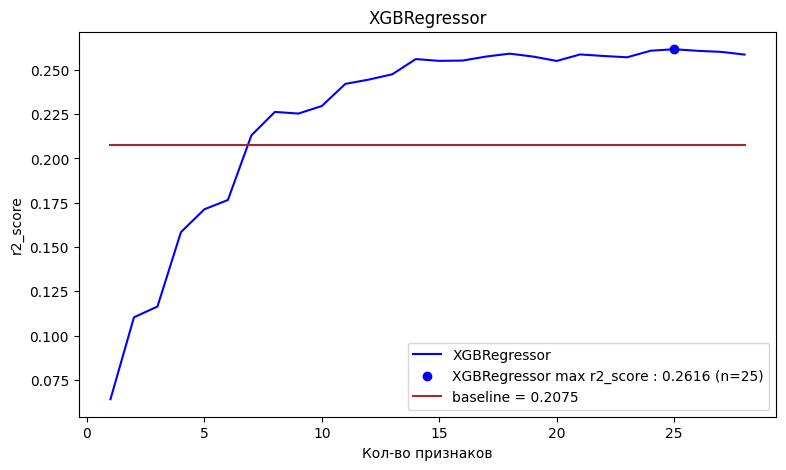

In [219]:
# Делим данные на train и test
X = df9.select_dtypes(['bool', 'int', 'float']).drop(columns=['availability_30'])
y = df9['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

res = {
    'n': [],
    'rmse_test': [],
    'r2_score': [],
}

tree_reg.fit(X_train, y_train)

feature_importance_list = pd.Series(tree_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

for n_col in tqdm(range(1, len(feature_importance_list.index))):

    tree_reg = xgb.XGBRegressor(
        n_estimators=100,       
        learning_rate=0.1,    
        max_depth=8,            
        objective='reg:squarederror', 
        random_state=42
    )

    # Оставляем только n самых важных признаков
    X_train_cut = X_train[feature_importance_list.index[:n_col]]
    X_test_cut = X_test[feature_importance_list.index[:n_col]]

    tree_reg.fit(X_train_cut, y_train)

    y_test_pred = tree_reg.predict(X_test_cut)

    res['n'] += [n_col]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='XGBRegressor',
    metric_col='r2_score',
    metric_nm='r2_score',
    x_label_name='Кол-во признаков',
    y_label_name='r2_score',
)



**Промежуточный вывод:**

Отбор топ N важных фичей практически не повлиял на качество модели

### Применение PCA
Попробуем уменьшить размерность и повысчить качество модели за счет применения PCA

In [186]:
from sklearn.decomposition import PCA

100%|██████████| 22/22 [00:07<00:00,  2.99it/s]


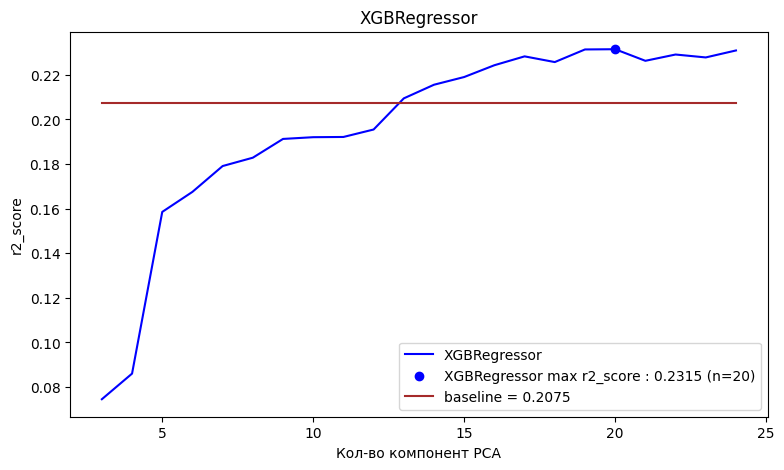

In [216]:
res = {
        'n': [],
        'rmse_test': [],
        'r2_score': [],
    }

for n in tqdm(range(3, 25)):

    pca = PCA(n_components=n)

    # Делим данные на train и test
    X = df9.select_dtypes(['bool', 'int', 'float']).drop(columns=['availability_30'])
    y = df9['availability_30']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    

    tree_reg = xgb.XGBRegressor(
    n_estimators=100,       
    learning_rate=0.1,    
    max_depth=7,            
    objective='reg:squarederror', 
    random_state=42
    )

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['r2_score'] += [r2_score(y_true=y_test,y_pred=y_test_pred)]

dtr_df = pd.DataFrame(res)

draw_metric2(
    df_list=[dtr_df],
    nm_list=['XGBRegressor'],
    title_nm='XGBRegressor',
    metric_col='r2_score',
    metric_nm='r2_score',
    x_label_name='Кол-во компонент PCA',
    y_label_name='r2_score',
)

**Промежуточный вывод:**

Использование алгортима PCA ухудшило качество модели

## Вывод

Не удалось создать хорошую модель предсказания метрики availability_30.

Лучшего всего показала себя модель XGBRegressor со следующими гипераметрами:
* n_estimators=100      
* learning_rate=0.1   
* max_depth=7           
* objective='reg:squarederror'

Большое влияние на качество модели оказал feature enginiring, особеннно фичи, касающиеся локации.
Так же качество модели удалось повысить за счет использований топ 25 самы важных фичей

**Итоговое качество модели:**
R^2 = 0.2616

Гипотезы, почему не удалось добиться лучшего качества модели:
1. Не хватило фич, напрямую влияющих на целевую метрику. Например стоимость за ночь
2. Нерелевантность некоторых показателей